# Model Evaluation (Base vs Modified)
This notebook compares base and modified checkpoints on three datasets: RSICD, RSITMD, and UCM_captions.
Each evaluation reports R@1, R@5, R@10 for Image-to-Text and Text-to-Image, plus mean recall.

In [21]:
import os
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

from dataset_loader import create_dataloaders
from eval import evaluate_recall
from model.dgtrs_longclip import DGTRSLongCLIP

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_ckpt = "checkpoints/base_model.pt"
modified_ckpt = "checkpoints/best_model.pt"

rsicd_test_csv = "dataset/test/rsicd_test.csv"
rsitmd_test_csv = "dataset/test/rsitmd_test.csv"
original_image_root = "images"
original_fallback_roots = ["img"]

ucm_test_csv = "UCM_captions/ucm_test.csv"
ucm_image_root = "UCM_captions/imgs"
ucm_fallback_roots = []

image_size = 224
long_context_length = 248
short_truncate_length = 20

eval_batch_size = 32  # reduce if you hit GPU memory issues
num_workers = 2
use_amp = True

In [22]:
def _assert_path(path_str: str) -> None:
    path = Path(path_str)
    if not path.exists():
        raise FileNotFoundError(f"Missing path: {path}")


def build_eval_loader(
    csv_path: str,
    image_root: str,
    tokenization_mode: str,
    normalization_mode: str,
    fallback_roots: list[str],
):
    _assert_path(csv_path)
    _assert_path(image_root)

    tokenizer_name = (
        "distilbert-base-uncased"
        if tokenization_mode == "distilbert"
        else "unused"
    )

    train_loader, val_loader, _ = create_dataloaders(
        train_csv=csv_path,
        val_csv=csv_path,
        image_root=image_root,
        image_fallback_roots=fallback_roots,
        tokenizer_name=tokenizer_name,
        tokenization_mode=tokenization_mode,
        normalization_mode=normalization_mode,
        image_size=image_size,
        max_text_length=64,
        long_context_length=long_context_length,
        short_truncate_length=short_truncate_length,
        batch_size=eval_batch_size,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=False,
        val_split=0.01,
        seed=42,
    )
    return val_loader


def load_base_model(checkpoint_path: str) -> DGTRSLongCLIP:
    _assert_path(checkpoint_path)
    model = DGTRSLongCLIP(longclip_base_model="ViT-B/16")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"], strict=False)
    return model.to(device)


def load_modified_model(checkpoint_path: str) -> DGTRSLongCLIP:
    _assert_path(checkpoint_path)
    model = DGTRSLongCLIP(longclip_base_model="ViT-B/16")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"], strict=False)
    return model.to(device)


def run_eval(model, loader, model_family: str) -> dict:
    return evaluate_recall(
        model=model,
        loader=loader,
        device=device,
        use_amp=use_amp,
        model_family=model_family,
    )


def format_metrics(dataset_name: str, model_name: str, metrics: dict) -> dict:
    return {
        "dataset": dataset_name,
        "model": model_name,
        "i2t_r1": metrics["image_to_text_recall_at_1"],
        "i2t_r5": metrics["image_to_text_recall_at_5"],
        "i2t_r10": metrics["image_to_text_recall_at_10"],
        "t2i_r1": metrics["text_to_image_recall_at_1"],
        "t2i_r5": metrics["text_to_image_recall_at_5"],
        "t2i_r10": metrics["text_to_image_recall_at_10"],
        "mean_recall": metrics["mean_recall"],
    }

## Base model on RSICD test set

In [23]:
base_model = load_base_model(base_ckpt)
rsicd_loader_base = build_eval_loader(
    csv_path=rsicd_test_csv,
    image_root=original_image_root,
    tokenization_mode="longclip",
    normalization_mode="clip",
    fallback_roots=original_fallback_roots,
)
metrics_base_rsicd = run_eval(base_model, rsicd_loader_base, "longclip_approx")
print(metrics_base_rsicd)

Computing embeddings: 100%|██████████| 171/171 [1:05:12<00:00, 22.88s/batch]


{'image_to_text_recall_at_1': 0.031107045710086823, 'image_to_text_recall_at_5': 0.11601097881793976, 'image_to_text_recall_at_10': 0.1879231482744217, 'text_to_image_recall_at_1': 0.02543458342552185, 'text_to_image_recall_at_5': 0.12936870753765106, 'text_to_image_recall_at_10': 0.20658737421035767, 'recall_at_1': 0.028270814567804337, 'recall_at_5': 0.12268984317779541, 'recall_at_10': 0.19725526124238968, 'mean_recall': 0.11607197299599648, 'image_to_text_mean_recall': 0.11168039093414943, 'text_to_image_mean_recall': 0.12046355505784352}


## Modified model on RSICD test set

In [ ]:
modified_model = load_modified_model(modified_ckpt)
rsicd_loader_modified = build_eval_loader(
    csv_path=rsicd_test_csv,
    image_root=original_image_root,
    tokenization_mode="longclip",
    normalization_mode="clip",
    fallback_roots=original_fallback_roots,
)
metrics_modified_rsicd = run_eval(
    modified_model, rsicd_loader_modified, "longclip_approx"
 )
print(metrics_modified_rsicd)

Computing embeddings: 100%|██████████| 171/171 [1:18:04<00:00, 27.39s/batch]


{'image_to_text_recall_at_1': 0.031655993312597275, 'image_to_text_recall_at_5': 0.11637694388628006, 'image_to_text_recall_at_10': 0.2038426399230957, 'text_to_image_recall_at_1': 0.02781335823237896, 'text_to_image_recall_at_5': 0.1359560787677765, 'text_to_image_recall_at_10': 0.2179322987794876, 'recall_at_1': 0.029734675772488117, 'recall_at_5': 0.12616651132702827, 'recall_at_10': 0.21088746935129166, 'mean_recall': 0.12226288548360269, 'image_to_text_mean_recall': 0.11729185904065768, 'text_to_image_mean_recall': 0.12723391192654768}


## Base model on RSITMD test set

In [24]:
rsitmd_loader_base = build_eval_loader(
    csv_path=rsitmd_test_csv,
    image_root=original_image_root,
    tokenization_mode="longclip",
    normalization_mode="clip",
    fallback_roots=original_fallback_roots,
)
metrics_base_rsitmd = run_eval(base_model, rsitmd_loader_base, "longclip_approx")
print(metrics_base_rsitmd)

Computing embeddings: 100%|██████████| 71/71 [27:34<00:00, 23.31s/batch] 


{'image_to_text_recall_at_1': 0.04557522013783455, 'image_to_text_recall_at_5': 0.17699114978313446, 'image_to_text_recall_at_10': 0.30000001192092896, 'text_to_image_recall_at_1': 0.03849557414650917, 'text_to_image_recall_at_5': 0.19380530714988708, 'text_to_image_recall_at_10': 0.3137168288230896, 'recall_at_1': 0.04203539714217186, 'recall_at_5': 0.18539822846651077, 'recall_at_10': 0.3068584203720093, 'mean_recall': 0.17809734866023064, 'image_to_text_mean_recall': 0.17418879394729933, 'text_to_image_mean_recall': 0.18200590337316194}


## Modified model on RSITMD test set

In [ ]:
rsitmd_loader_modified = build_eval_loader(
    csv_path=rsitmd_test_csv,
    image_root=original_image_root,
    tokenization_mode="longclip",
    normalization_mode="clip",
    fallback_roots=original_fallback_roots,
)
metrics_modified_rsitmd = run_eval(
    modified_model, rsitmd_loader_modified, "longclip_approx"
 )
print(metrics_modified_rsitmd)

Computing embeddings: 100%|██████████| 71/71 [28:15<00:00, 23.88s/batch] 


{'image_to_text_recall_at_1': 0.04336283355951309, 'image_to_text_recall_at_5': 0.1898230016231537, 'image_to_text_recall_at_10': 0.30707964301109314, 'text_to_image_recall_at_1': 0.03849557414650917, 'text_to_image_recall_at_5': 0.20088495314121246, 'text_to_image_recall_at_10': 0.32654866576194763, 'recall_at_1': 0.04092920385301113, 'recall_at_5': 0.19535397738218307, 'recall_at_10': 0.3168141543865204, 'mean_recall': 0.18436577854057154, 'image_to_text_mean_recall': 0.1800884927312533, 'text_to_image_mean_recall': 0.18864306434988976}


## Base model on UCM_captions dataset

In [25]:
ucm_loader_base = build_eval_loader(
    csv_path=ucm_test_csv,
    image_root=ucm_image_root,
    tokenization_mode="longclip",
    normalization_mode="clip",
    fallback_roots=ucm_fallback_roots,
)
metrics_base_ucm = run_eval(base_model, ucm_loader_base, "longclip_approx")
print(metrics_base_ucm)

Computing embeddings: 100%|██████████| 33/33 [12:44<00:00, 23.16s/batch]

{'image_to_text_recall_at_1': 0.034285712987184525, 'image_to_text_recall_at_5': 0.14761905372142792, 'image_to_text_recall_at_10': 0.24095238745212555, 'text_to_image_recall_at_1': 0.022857142612338066, 'text_to_image_recall_at_5': 0.14095237851142883, 'text_to_image_recall_at_10': 0.24095238745212555, 'recall_at_1': 0.028571427799761295, 'recall_at_5': 0.14428571611642838, 'recall_at_10': 0.24095238745212555, 'mean_recall': 0.13793651045610508, 'image_to_text_mean_recall': 0.140952384720246, 'text_to_image_mean_recall': 0.13492063619196415}


## Modified model on UCM_captions dataset

In [ ]:
ucm_loader_modified = build_eval_loader(
    csv_path=ucm_test_csv,
    image_root=ucm_image_root,
    tokenization_mode="longclip",
    normalization_mode="clip",
    fallback_roots=ucm_fallback_roots,
)
metrics_modified_ucm = run_eval(
    modified_model, ucm_loader_modified, "longclip_approx"
 )
print(metrics_modified_ucm)

Computing embeddings: 100%|██████████| 33/33 [13:13<00:00, 24.04s/batch]

{'image_to_text_recall_at_1': 0.032380953431129456, 'image_to_text_recall_at_5': 0.13904762268066406, 'image_to_text_recall_at_10': 0.24190476536750793, 'text_to_image_recall_at_1': 0.022857142612338066, 'text_to_image_recall_at_5': 0.1314285695552826, 'text_to_image_recall_at_10': 0.23523809015750885, 'recall_at_1': 0.02761904802173376, 'recall_at_5': 0.13523809611797333, 'recall_at_10': 0.2385714277625084, 'mean_recall': 0.13380952396740517, 'image_to_text_mean_recall': 0.1377777804931005, 'text_to_image_mean_recall': 0.12984126744170985}


## Compare results across datasets

Dataset | Model | I2T R@1 | I2T R@5 | I2T R@10 | T2I R@1 | T2I R@5 | T2I R@10 | Mean Recall
--------------------------------------------------------------------------------------------------------------
RSICD  | Base     | 0.0311 | 0.1160 | 0.1879 | 0.0254 | 0.1294 | 0.2066 | 0.1161
RSICD  | Modified | 0.0317 | 0.1164 | 0.2038 | 0.0278 | 0.1360 | 0.2179 | 0.1223
RSITMD | Base     | 0.0456 | 0.1770 | 0.3000 | 0.0385 | 0.1938 | 0.3137 | 0.1781
RSITMD | Modified | 0.0434 | 0.1898 | 0.3071 | 0.0385 | 0.2009 | 0.3265 | 0.1844
UCM    | Base     | 0.0343 | 0.1476 | 0.2410 | 0.0229 | 0.1410 | 0.2410 | 0.1379
UCM    | Modified | 0.0324 | 0.1390 | 0.2419 | 0.0229 | 0.1314 | 0.2352 | 0.1338


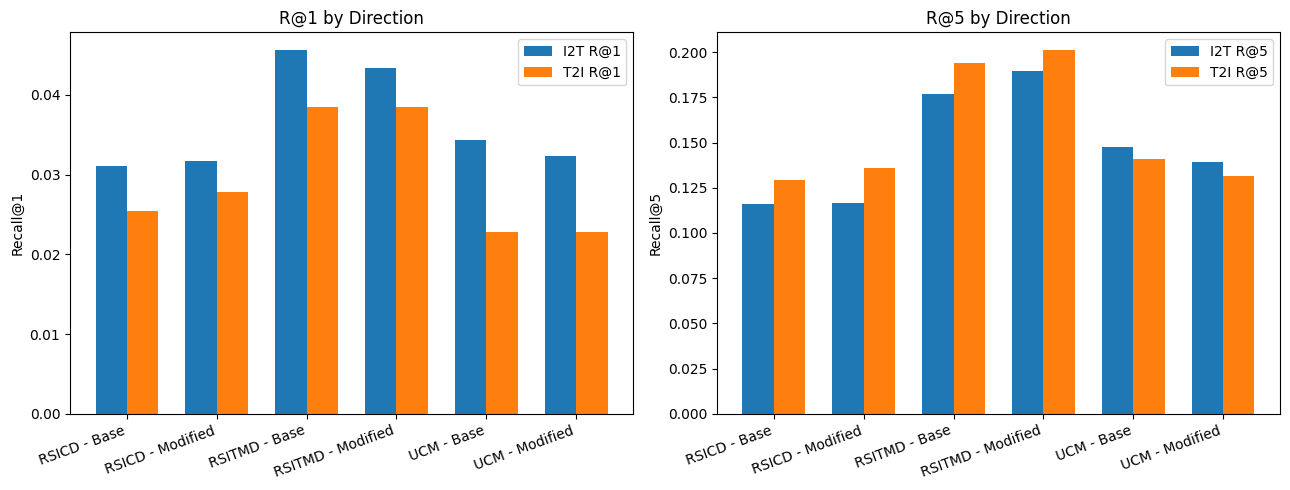

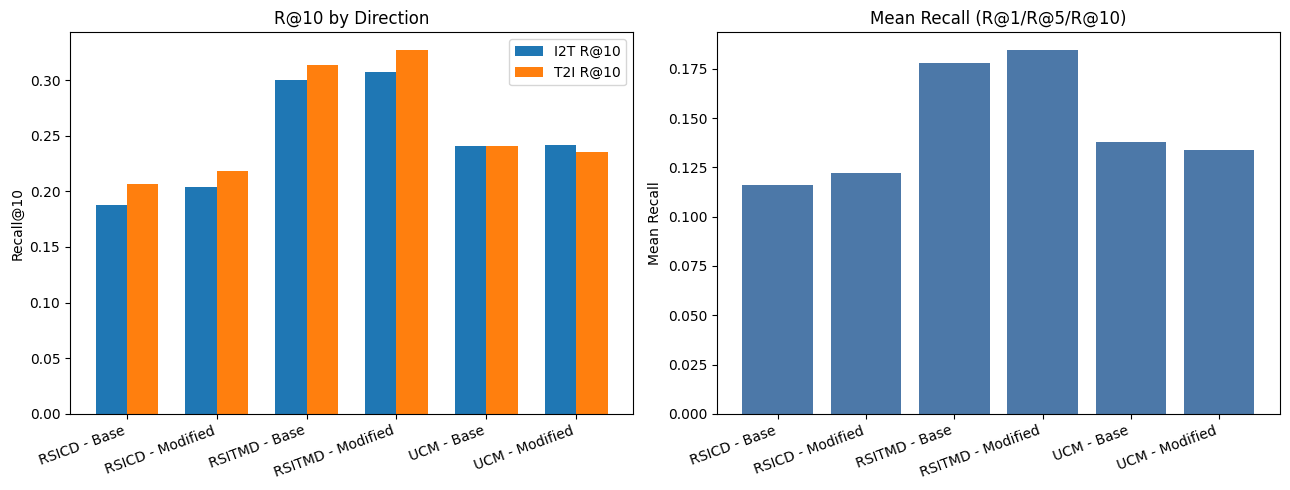

In [29]:
results = [
    format_metrics("RSICD", "Base", metrics_base_rsicd),
    format_metrics("RSICD", "Modified", metrics_modified_rsicd),
    format_metrics("RSITMD", "Base", metrics_base_rsitmd),
    format_metrics("RSITMD", "Modified", metrics_modified_rsitmd),
    format_metrics("UCM", "Base", metrics_base_ucm),
    format_metrics("UCM", "Modified", metrics_modified_ucm),
]

print("Dataset | Model | I2T R@1 | I2T R@5 | I2T R@10 | T2I R@1 | T2I R@5 | T2I R@10 | Mean Recall")
print("-" * 110)
for row in results:
    print(
        f"{row['dataset']:6} | {row['model']:8} | "
        f"{row['i2t_r1']:.4f} | {row['i2t_r5']:.4f} | {row['i2t_r10']:.4f} | "
        f"{row['t2i_r1']:.4f} | {row['t2i_r5']:.4f} | {row['t2i_r10']:.4f} | "
        f"{row['mean_recall']:.4f}"
    )

labels = [f"{row['dataset']} - {row['model']}" for row in results]
mean_values = [row["mean_recall"] for row in results]
i2t_r10_values = [row["i2t_r10"] for row in results]
t2i_r10_values = [row["t2i_r10"] for row in results]
i2t_r1_values = [row["i2t_r1"] for row in results]
t2i_r1_values = [row["t2i_r1"] for row in results]
i2t_r5_values = [row["i2t_r5"] for row in results]
t2i_r5_values = [row["t2i_r5"] for row in results]

x = np.arange(len(labels))
width = 0.35

fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
axes2[0].bar(x - width / 2, i2t_r1_values, width, label="I2T R@1")
axes2[0].bar(x + width / 2, t2i_r1_values, width, label="T2I R@1")
axes2[0].set_title("R@1 by Direction")
axes2[0].set_ylabel("Recall@1")
axes2[0].set_xticks(x)
axes2[0].set_xticklabels(labels, rotation=20, ha="right")
axes2[0].legend()

axes2[1].bar(x - width / 2, i2t_r5_values, width, label="I2T R@5")
axes2[1].bar(x + width / 2, t2i_r5_values, width, label="T2I R@5")
axes2[1].set_title("R@5 by Direction")
axes2[1].set_ylabel("Recall@5")
axes2[1].set_xticks(x)
axes2[1].set_xticklabels(labels, rotation=20, ha="right")
axes2[1].legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(x - width / 2, i2t_r10_values, width, label="I2T R@10")
axes[0].bar(x + width / 2, t2i_r10_values, width, label="T2I R@10")
axes[0].set_title("R@10 by Direction")
axes[0].set_ylabel("Recall@10")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=20, ha="right")
axes[0].legend()

axes[1].bar(x, mean_values, color="#4C78A8")
axes[1].set_title("Mean Recall (R@1/R@5/R@10)")
axes[1].set_ylabel("Mean Recall")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=20, ha="right")

plt.tight_layout()
plt.show()